Importing libraries

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as mp
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Training dataset Preprocessing

In [5]:
training_set = tf.keras.utils.image_dataset_from_directory(
    './train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 2398 files belonging to 5 classes.


I0000 00:00:1776769199.787882     990 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5562 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6


Validation dataset preprocessing

In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    './validate',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 469 files belonging to 5 classes.


Building Model

In [7]:
cnn = tf.keras.models.Sequential()

adding convolution layers

In [8]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu',input_shape=[224,224,3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

/mnt/c/Users/Bitlocker1/ml/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [10]:
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [11]:
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [12]:
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [13]:
cnn.add(tf.keras.layers.Flatten())

adding neural network

In [14]:
cnn.add(tf.keras.layers.Dense(units=128,activation='relu')) 
cnn.add(tf.keras.layers.Dropout(0.5))   #to avoid overfitting 

adding output layer

In [15]:
cnn.add(tf.keras.layers.Dense(units=5,activation='softmax'))

compiling and Training

In [16]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )

In [17]:
early_stop = tf.keras.callbacks.EarlyStopping(   #to stop before overfitting
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [18]:
training_history = cnn.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30


2026-04-21 13:00:16.752929: I external/local_xla/xla/service/service.cc:163] XLA service 0x7dca340063b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-21 13:00:16.752982: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2026-04-21 13:00:18.015573: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-21 13:00:20.017489: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-04-21 13:00:20.998672: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-21 13:00:25.556146: I e

75/75 ━━━━━━━━━━━━━━━━━━━━ 75s 573ms/step - accuracy: 0.6276 - loss: 1.5326 - val_accuracy: 0.8785 - val_loss: 0.3763
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9020 - loss: 0.2812 - val_accuracy: 0.9019 - val_loss: 0.2394
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9562 - loss: 0.1460 - val_accuracy: 0.9126 - val_loss: 0.2815
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9566 - loss: 0.1273 - val_accuracy: 0.9339 - val_loss: 0.2578
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9721 - loss: 0.0931 - val_accuracy: 0.9787 - val_loss: 0.1875
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9821 - loss: 0.0572 - val_accuracy: 0.9382 - val_loss: 0.3338
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9821 - loss: 0.0526 - val_accuracy: 0.9104 - val_loss: 0.4549
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9666 - loss: 0.0914 - val_accuracy: 0.9254 - val_loss: 

Saving model

In [ ]:
# cnn.save('trained_model.keras')

Recording history as json

In [ ]:
# import json
# with open('training_history.json','w') as f:
#     json.dump(training_history.history,f)

accuracy visualization

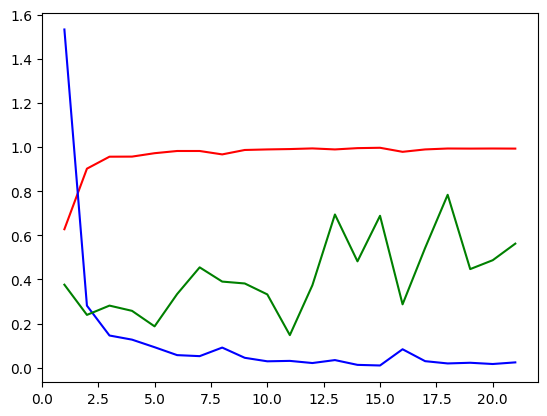

In [34]:
epochs = [i for i in range(1,22)]
mp.plot(epochs,training_history.history['accuracy'],color='red')
mp.plot(epochs,training_history.history['loss'],color='blue')
mp.plot(epochs,training_history.history['val_loss'],color='green')